In [ ]:
print("Welcome to Machine Learning 🚀")

Welcome to Machine Learning 🚀


In [17]:
import pandas as pd

# Assuming 'SMSSpamCollection' is in the 'Colab Notebooks' folder in your Google Drive.
# Adjust the path if your file is located elsewhere.
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/SMSSpamCollection.csv',
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.shape

(5572, 2)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [20]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [21]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


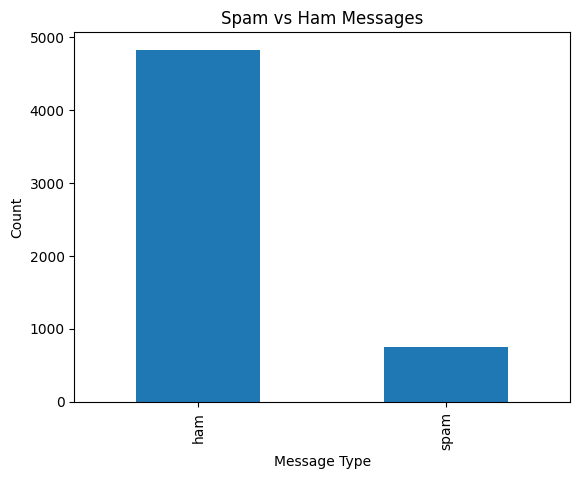

In [22]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [23]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
X = df["message"]
y = df["label"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [27]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9668161434977578


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 37 112]]


In [38]:
message = ["URGENT! You have won ₹100000. Click the link to claim your prize now."]
message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")


Spam Email


In [36]:
message = ["Hi Kashak, are we meeting tomorrow for our machine learning project?"]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam
